In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [50]:
df = pd.read_csv("crime_total_cases.csv")
df.head()

,time,DMP,CMP,KMP,RMP,BMP,SMP,RPMP,GMP,Dhaka Range,Mymensingh Range,Chittagong Range,Sylhet Range,Khulna Range,Barishal Range,Rajshahi Range,Rangpur Range,Railway Range
0,2019-01-01,2153,678,317,401,166,143,121,244,3089,1004,2396,725,1585,895,2011,1472,84
1,2019-02-01,2040,571,265,396,134,120,128,287,2855,1047,2608,724,1781,870,2248,1501,87
2,2019-03-01,2433,674,285,362,160,155,108,353,2958,1001,2378,738,1505,926,2015,1417,89
3,2019-04-01,2515,763,260,533,169,166,153,319,3591,1174,2893,825,1610,1067,2276,1721,100
4,2019-05-01,2636,936,183,460,184,176,145,327,3673,1253,3166,921,1690,1098,2278,1741,88


In [51]:
df.shape

(91, 18)

In [52]:
91//12

7

In [53]:
df.drop(columns=['time'], inplace=True)

### Only using data of 25 days

In [54]:
df = df[:7*12]
# df = hourly[:25*24]
df_raw = df.copy()
df.head()

,DMP,CMP,KMP,RMP,BMP,SMP,RPMP,GMP,Dhaka Range,Mymensingh Range,Chittagong Range,Sylhet Range,Khulna Range,Barishal Range,Rajshahi Range,Rangpur Range,Railway Range
0,2153,678,317,401,166,143,121,244,3089,1004,2396,725,1585,895,2011,1472,84
1,2040,571,265,396,134,120,128,287,2855,1047,2608,724,1781,870,2248,1501,87
2,2433,674,285,362,160,155,108,353,2958,1001,2378,738,1505,926,2015,1417,89
3,2515,763,260,533,169,166,153,319,3591,1174,2893,825,1610,1067,2276,1721,100
4,2636,936,183,460,184,176,145,327,3673,1253,3166,921,1690,1098,2278,1741,88


In [55]:
scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df)
df.head()

,DMP,CMP,KMP,RMP,BMP,SMP,RPMP,GMP,Dhaka Range,Mymensingh Range,Chittagong Range,Sylhet Range,Khulna Range,Barishal Range,Rajshahi Range,Rangpur Range,Railway Range
0,0.288721,1.237442,3.423453,1.167265,0.772030,-0.858089,0.141736,-0.027861,1.505298,-0.292233,-0.063691,0.168903,0.229149,0.629856,0.012802,-0.065627,1.283105
1,0.065113,0.463998,2.280383,1.120039,-0.325968,-1.495224,0.375840,0.712100,0.890556,-0.044917,0.663828,0.157516,1.226694,0.387471,0.687041,0.111610,1.426430
2,0.842794,1.208529,2.720025,0.798904,0.566155,-0.525670,-0.293028,1.847855,1.161148,-0.309487,-0.125461,0.316930,-0.178012,0.930415,0.024182,-0.401765,1.521980
3,1.005059,1.851861,2.170472,2.414027,0.874968,-0.220953,1.211925,1.262769,2.824104,0.685528,1.641859,1.307573,0.356387,2.297470,0.766698,1.456163,2.047507
4,1.244498,3.102383,0.477849,1.724530,1.389654,0.056063,0.944378,1.400437,3.039526,1.139900,2.578711,2.400696,0.763548,2.598028,0.772388,1.578395,1.474205


### Smoothing using rolling mean

In [56]:
# # make each numeric column smooth by rolling mean
# numeric_cols = df.select_dtypes(include='number').columns
# df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

# for col in ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']:
#     plt.figure(figsize=(12, 4))
#     plt.plot(df[col][:10000])
#     plt.title(f"{col} over time (smoothed)")

In [57]:
TOTAL_POINTS = len(df)
PERIOD = 7
TRAIN_DAYS = 5
TEST_DAYS = 2
TIME = TOTAL_POINTS // PERIOD
FEATURES = len(df.columns)
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 7 x 12 x 17


In [58]:
PERIOD*TIME

84

In [59]:
# data = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
# data = df[['DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
data = df[:PERIOD*TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(7, 12, 17)

In [60]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (5, 12, 17)
Test tensor shape: (2, 12, 17)


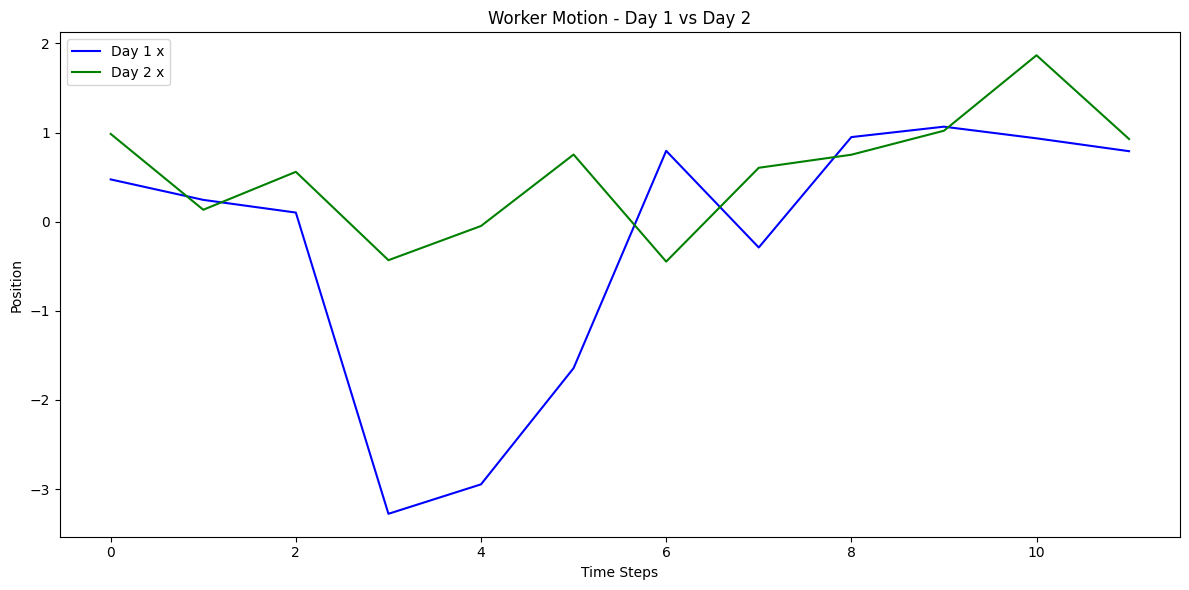

In [61]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [62]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (5, 2)
Time factors shape: (12, 2)
Feature factors shape: (17, 2)


In [63]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (5, 12, 17)
Reconstructed tensor shape: (5, 12, 17)


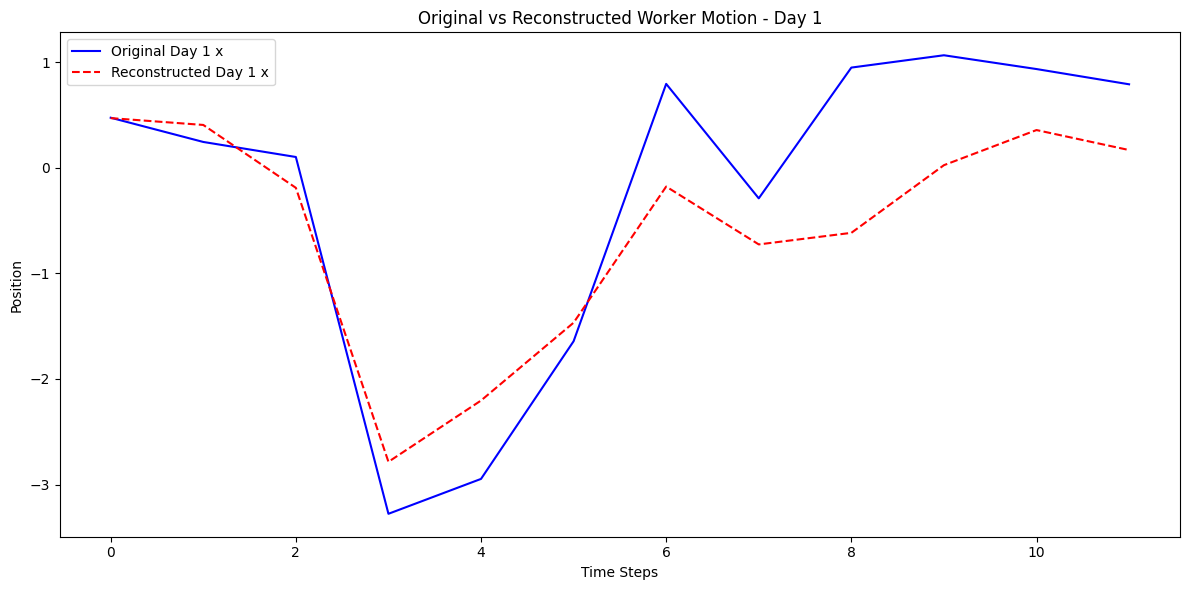

In [64]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [65]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

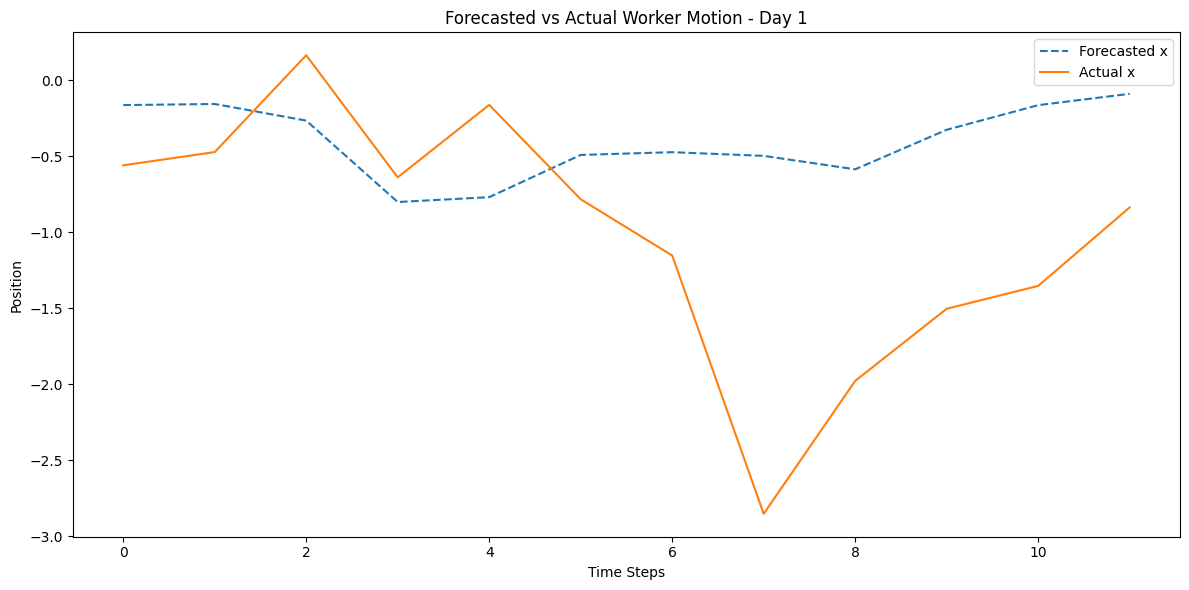

In [66]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

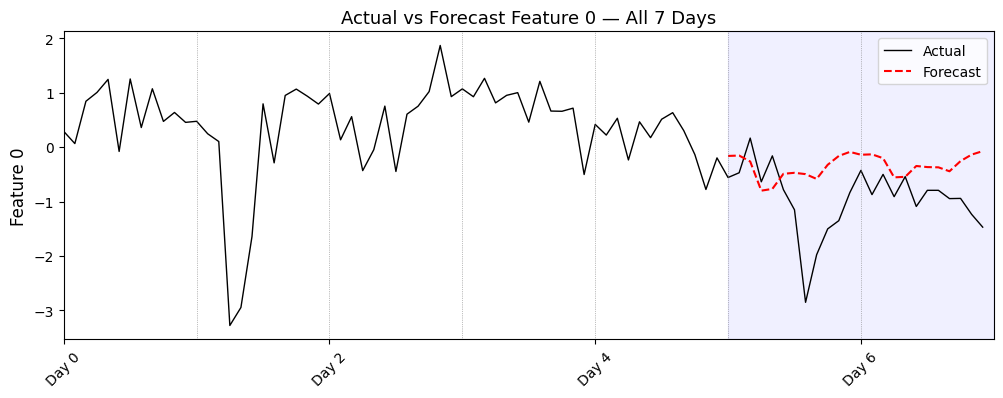

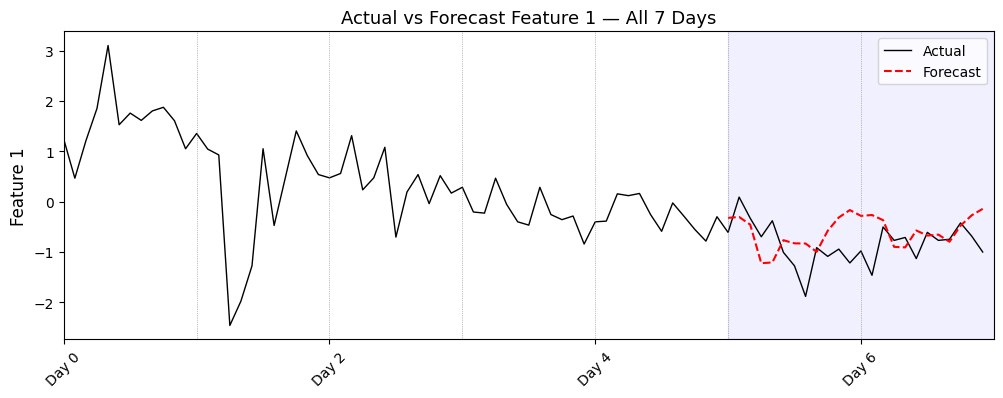

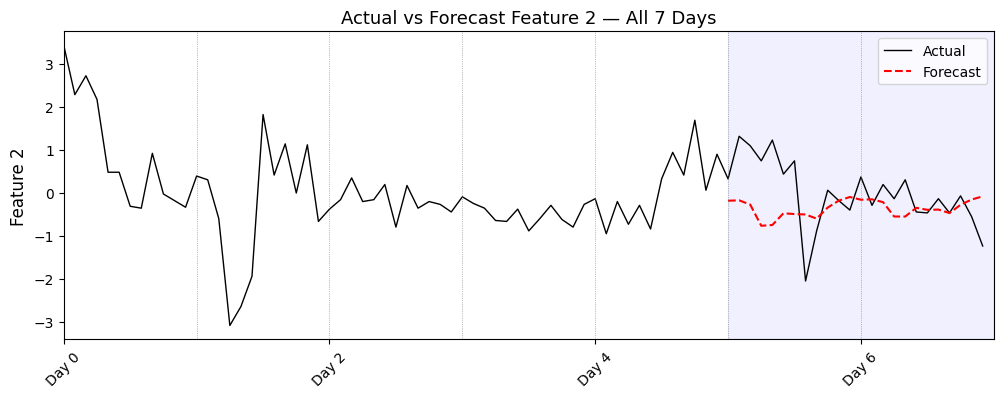

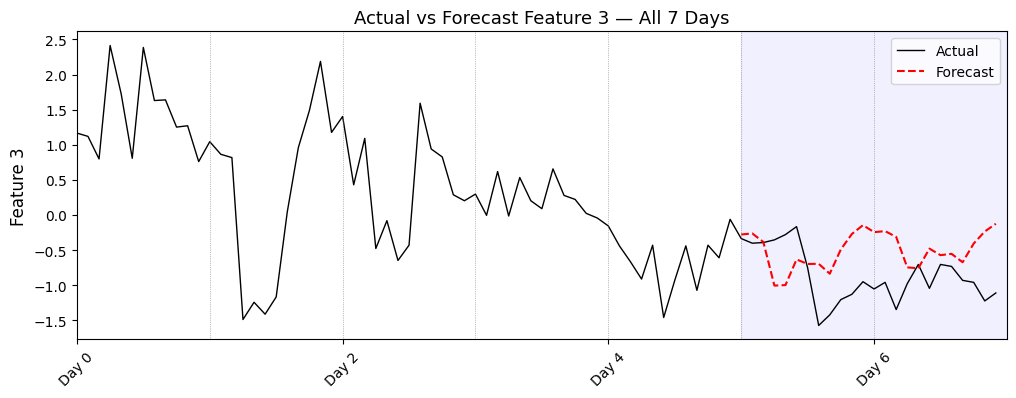

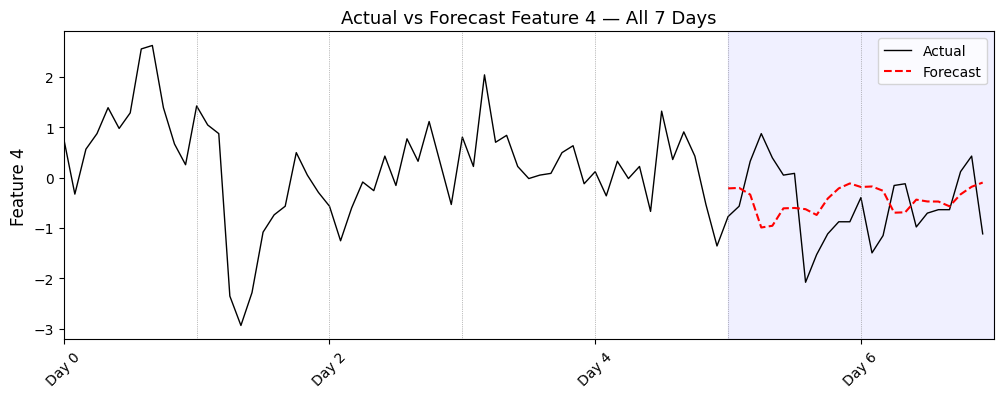

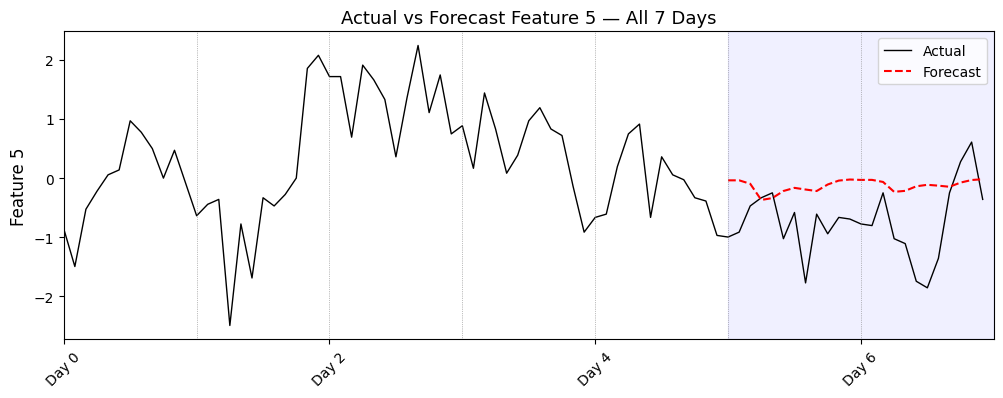

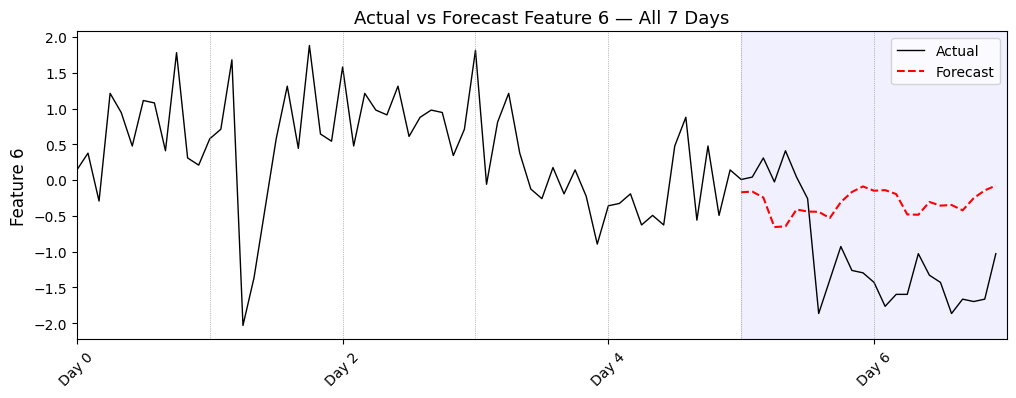

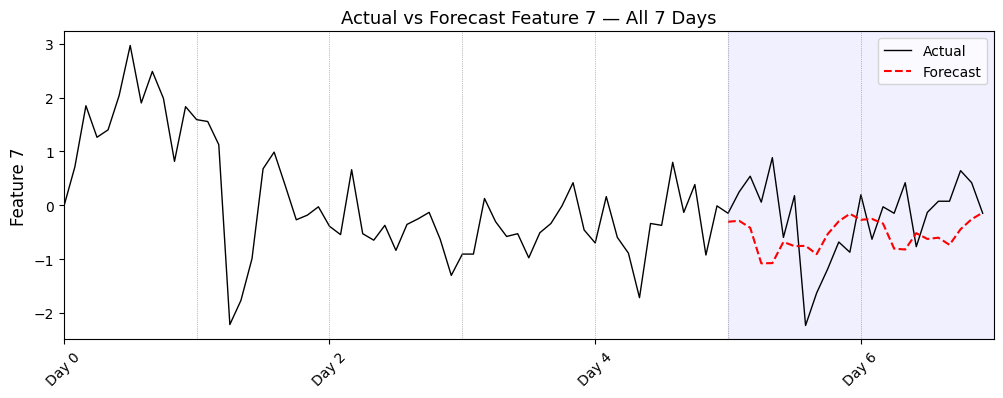

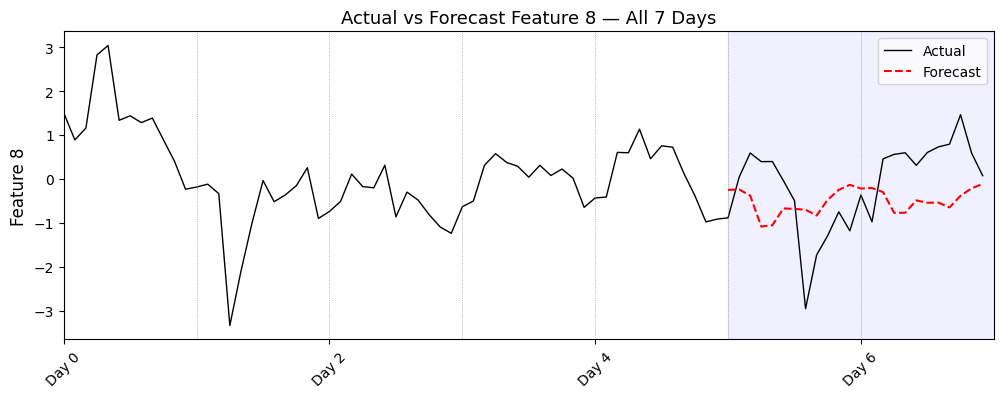

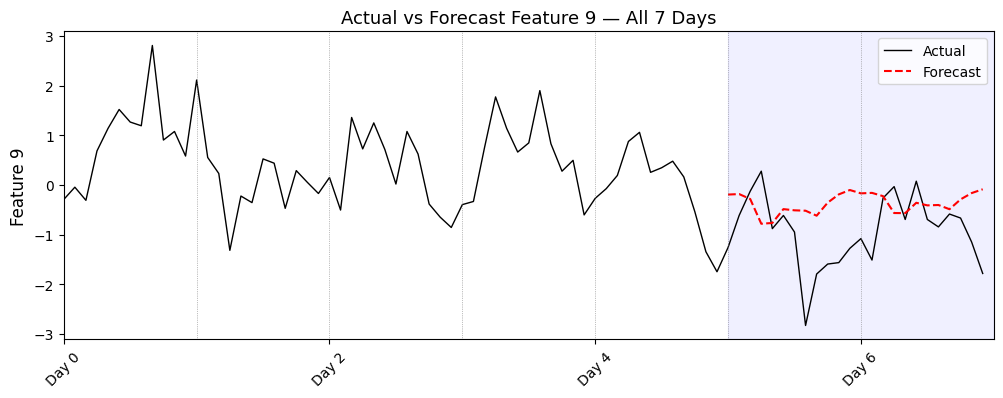

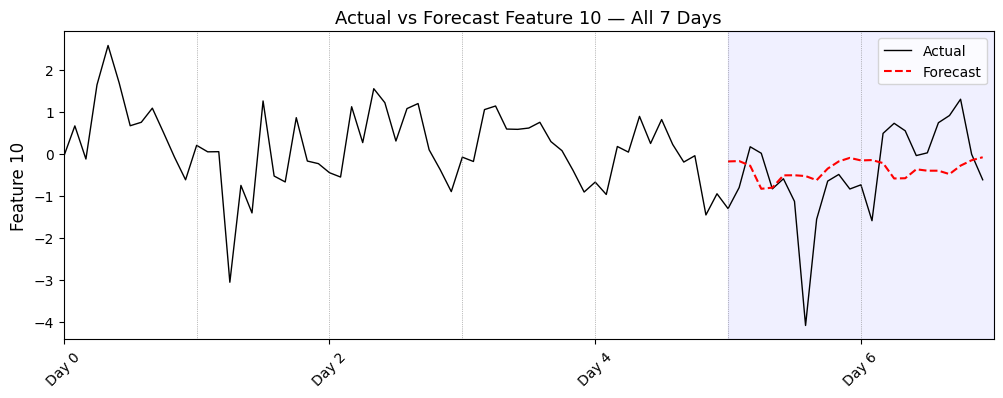

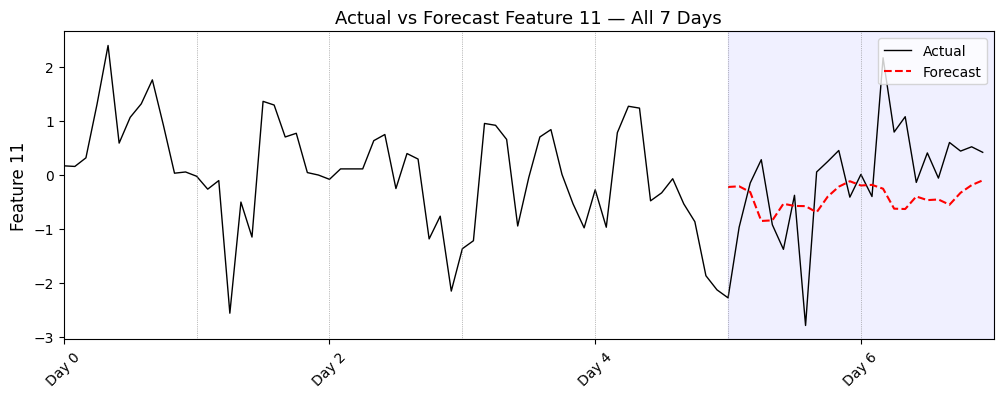

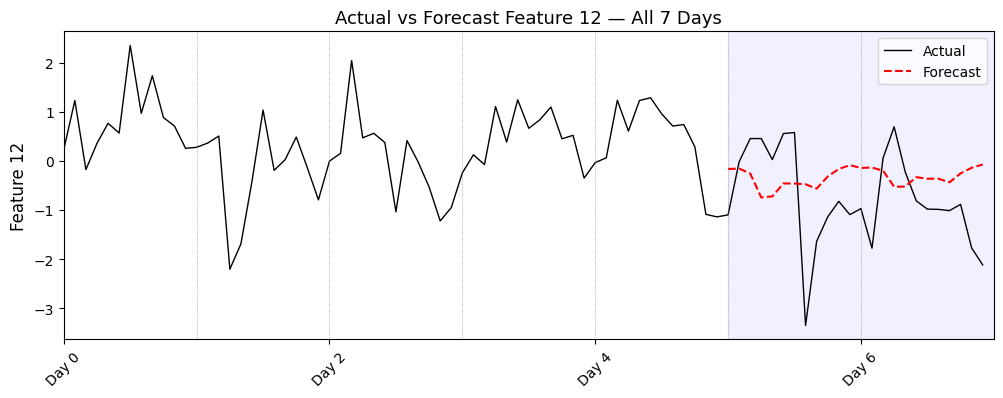

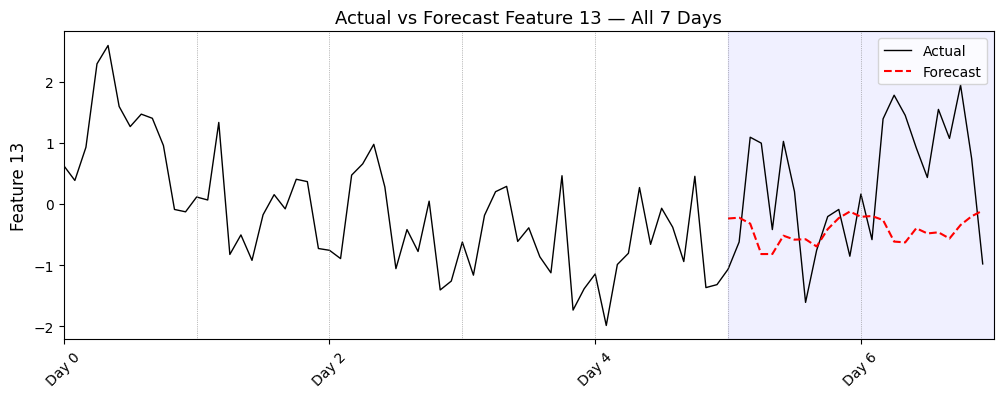

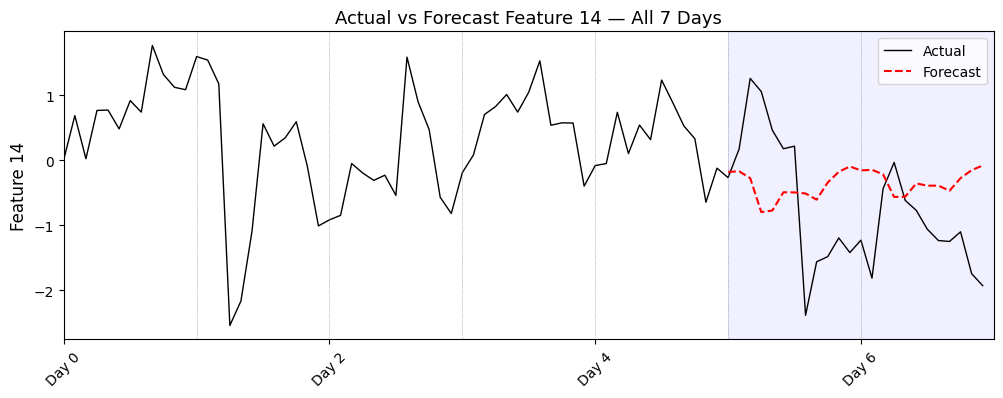

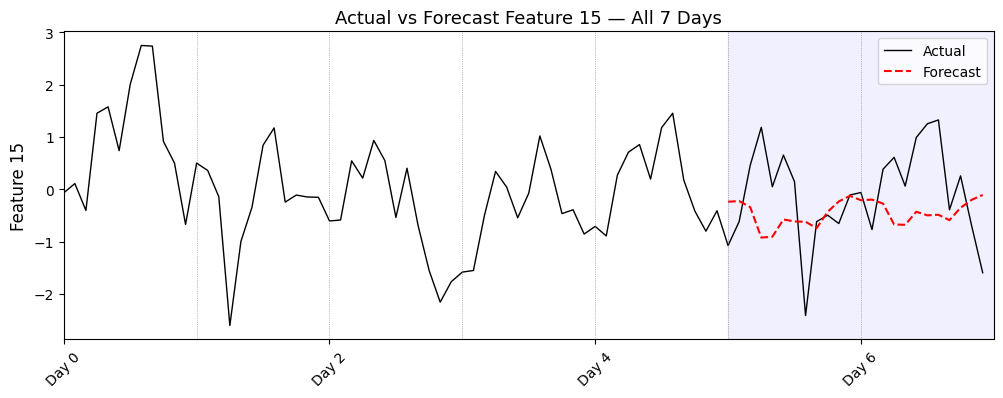

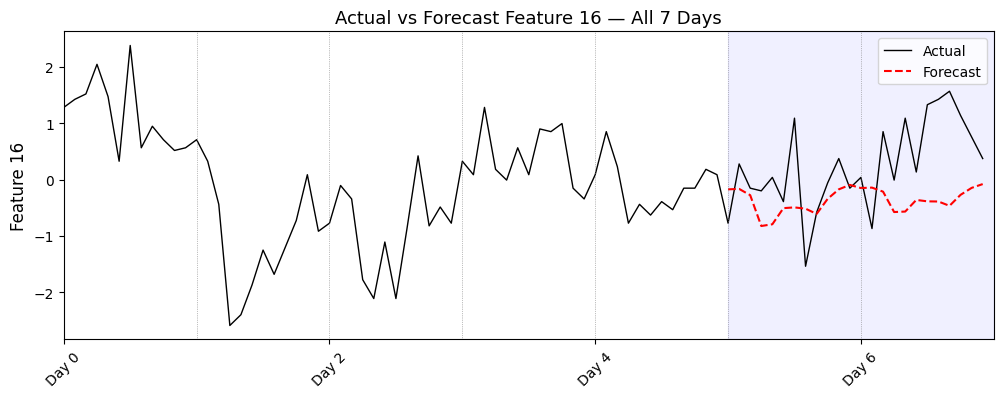

In [67]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    plt.plot(x_forecast, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
    plt.xticks(np.arange(0, T + 1, 2 * TIME),
               [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
    plt.xlim(0, T)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.title(f'Actual vs Forecast Feature {i} — All {PERIOD} Days', fontsize=13)
    plt.legend(loc='upper right')

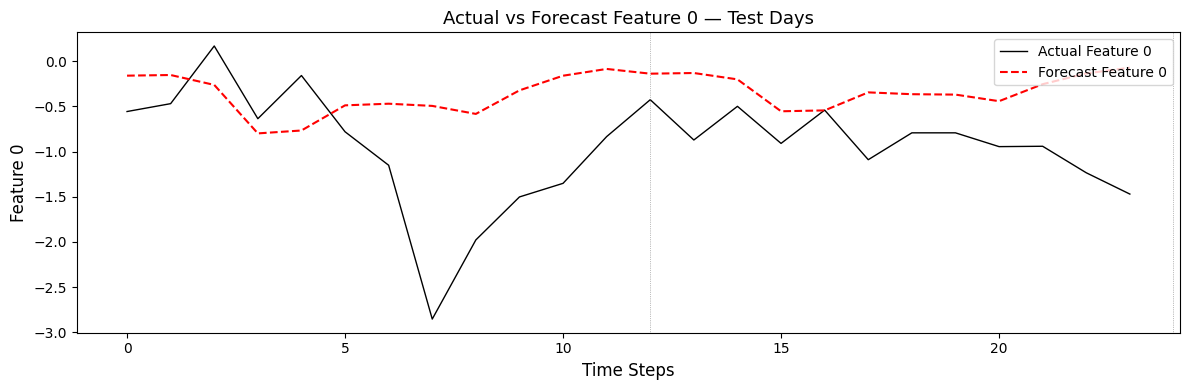

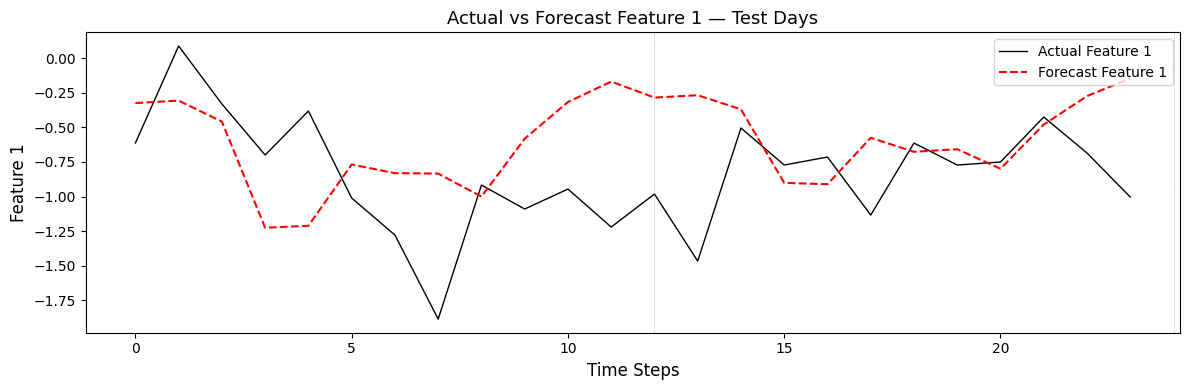

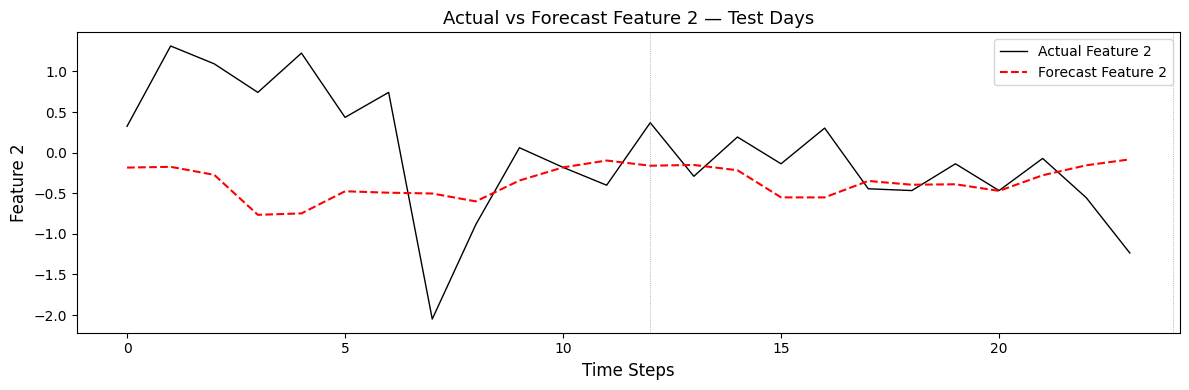

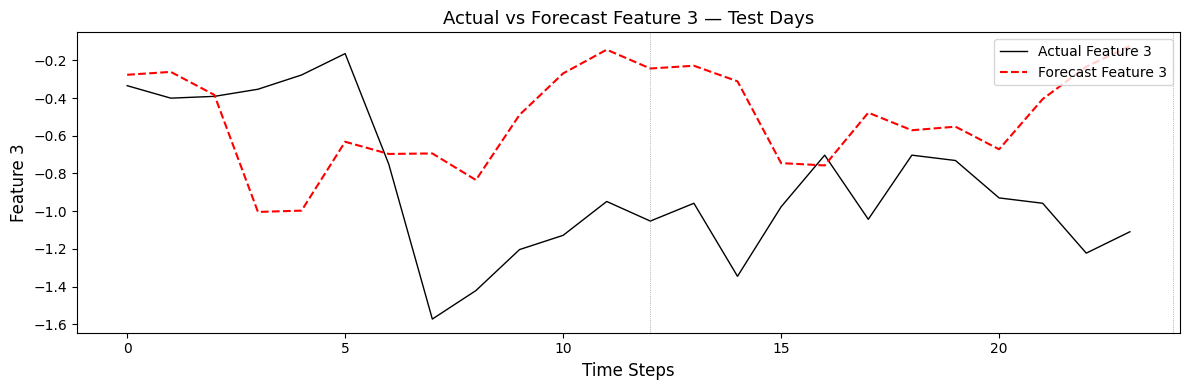

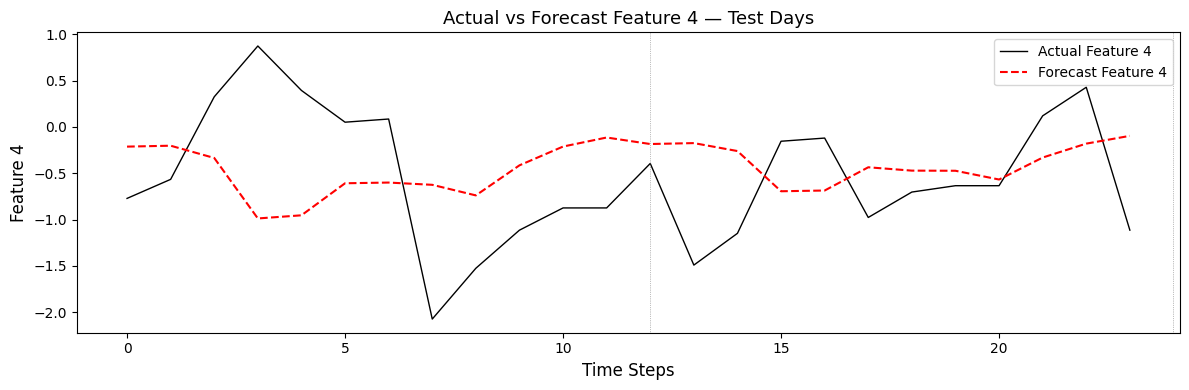

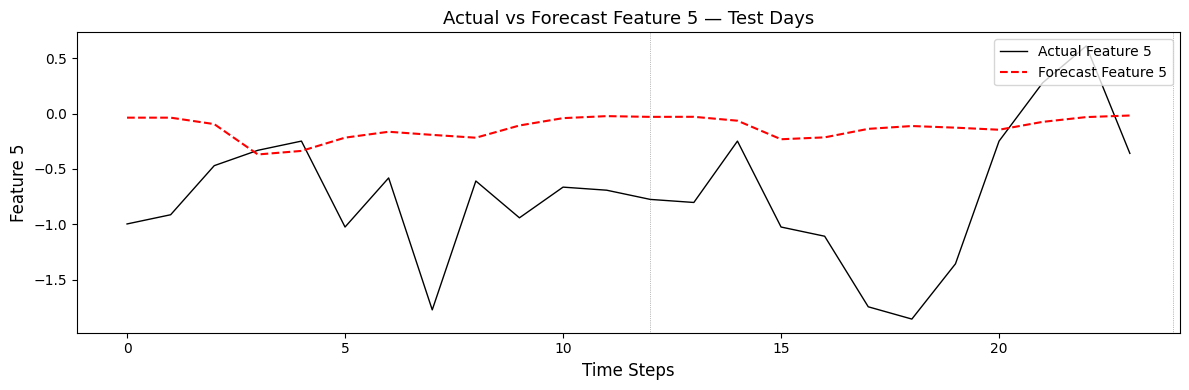

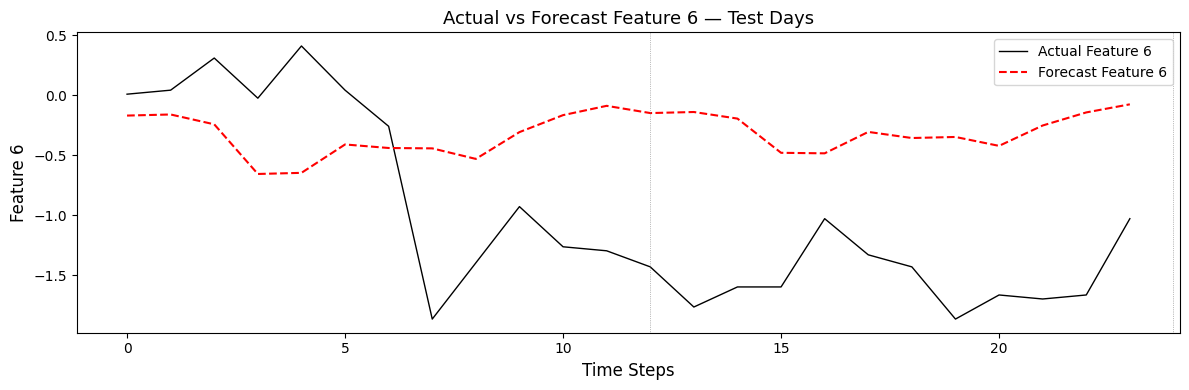

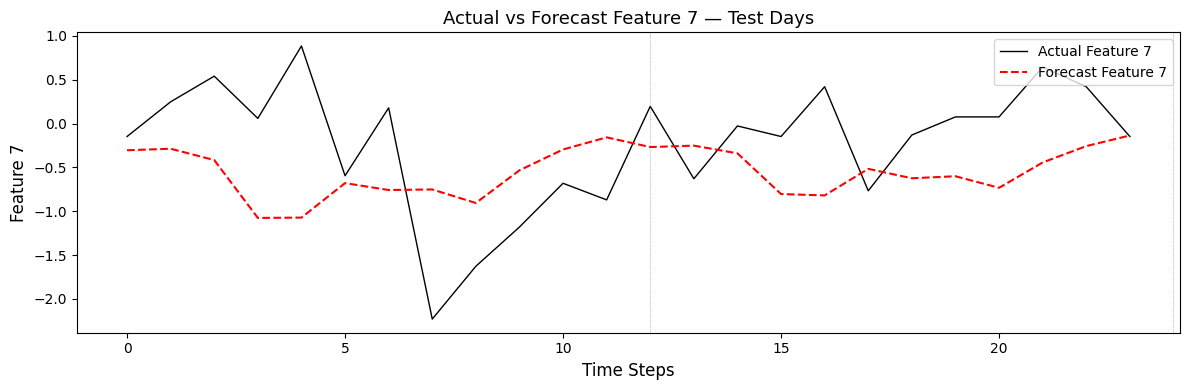

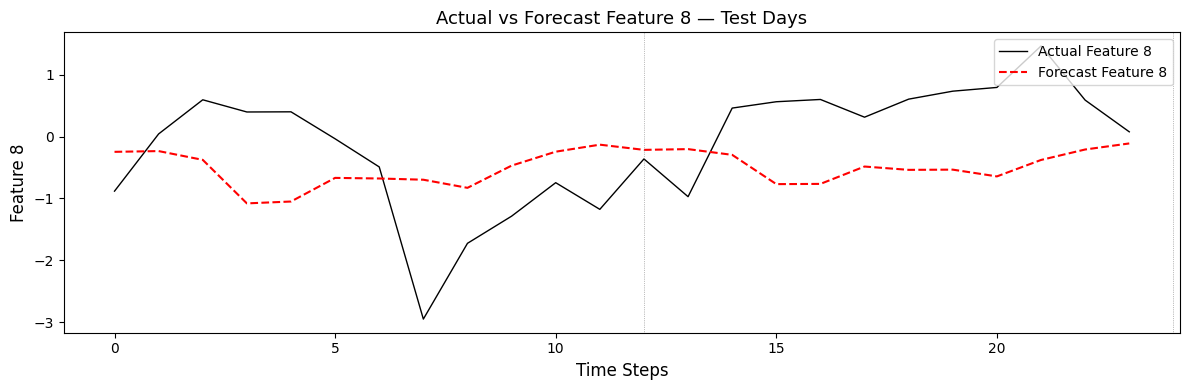

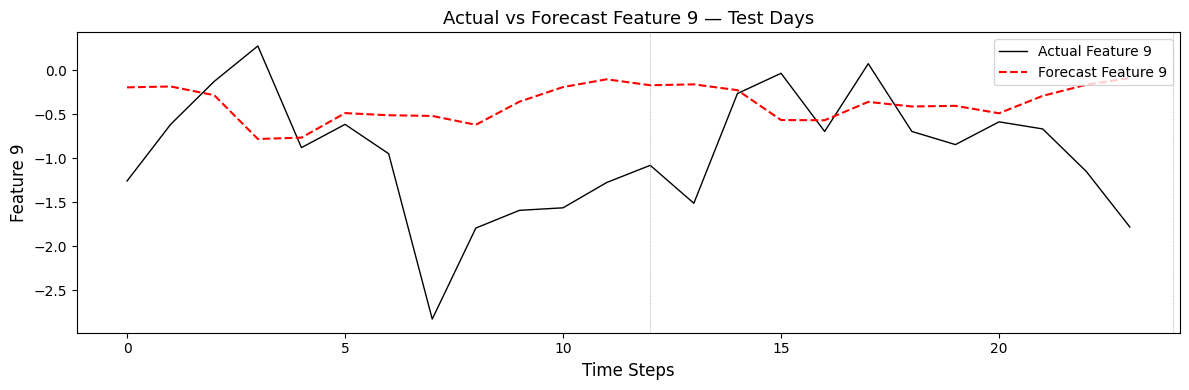

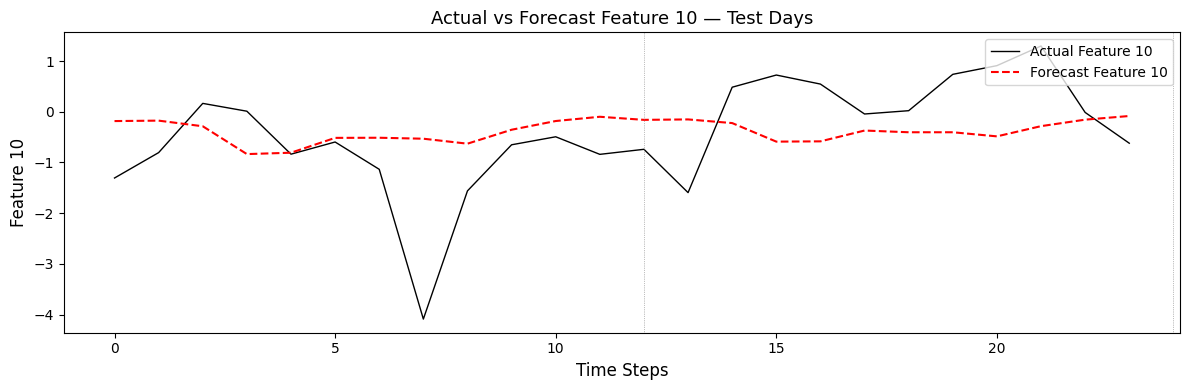

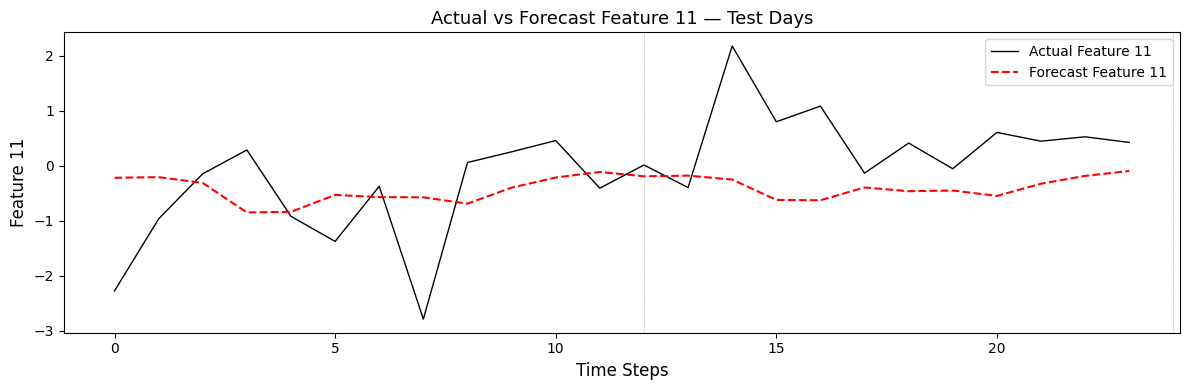

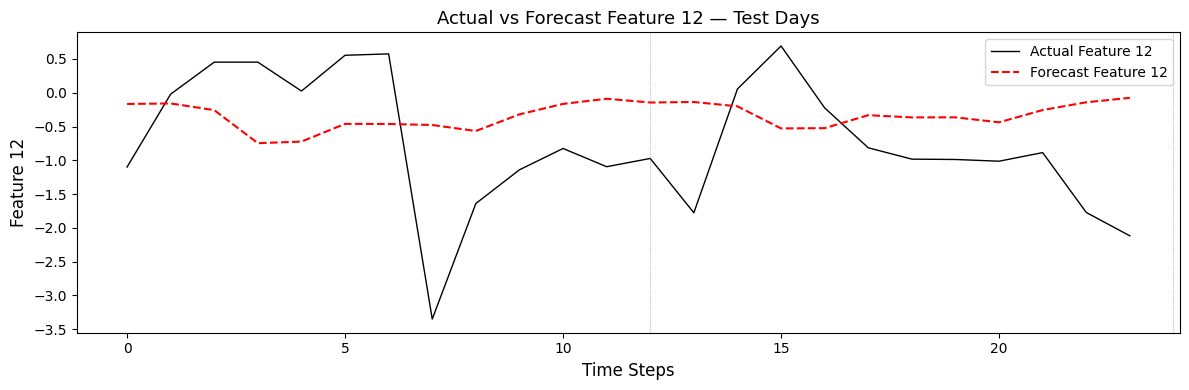

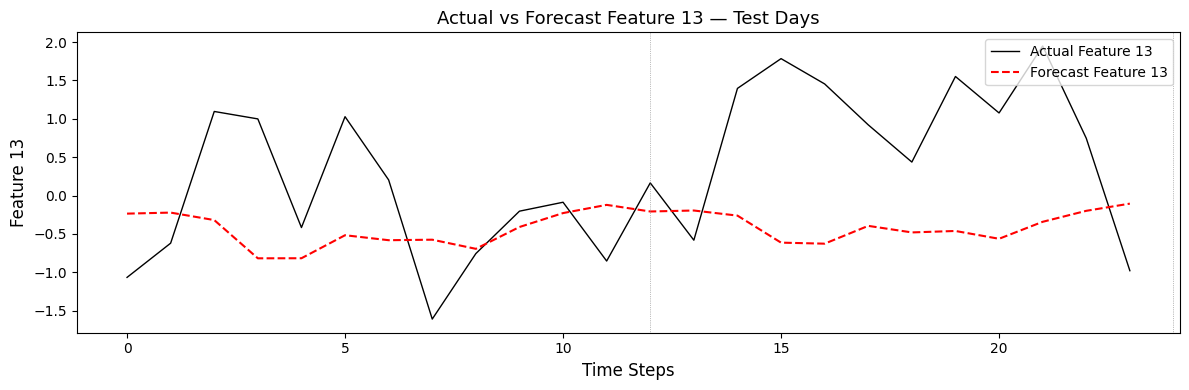

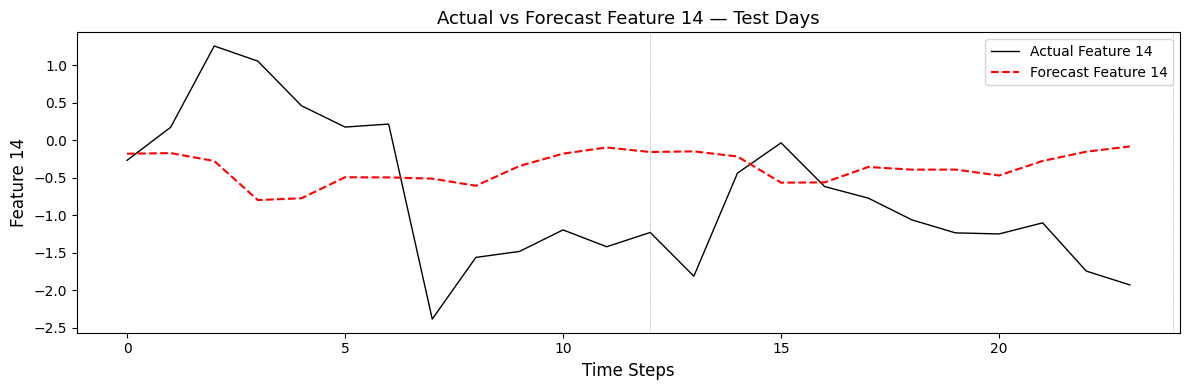

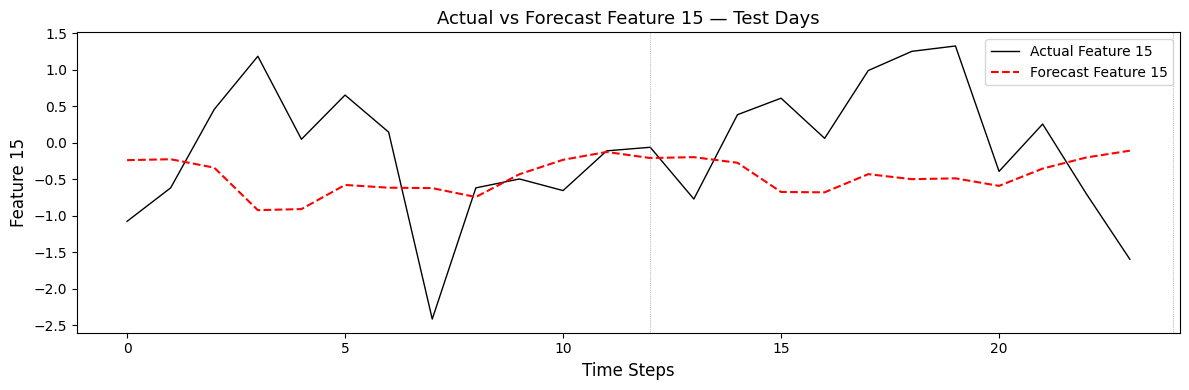

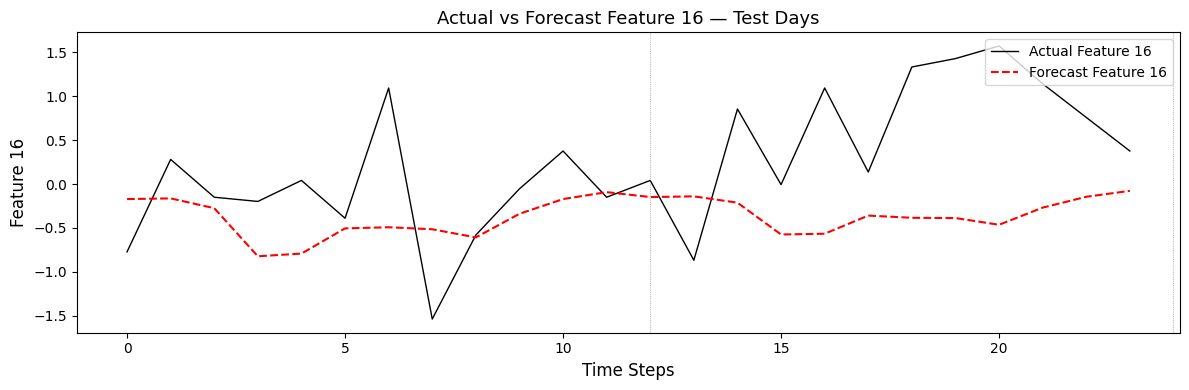

In [68]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [69]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((60, 17), (24, 17))

In [70]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"Feature {i} R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

print("average R²: {:.4f}, average MSE: {:.4f}, average MAE: {:.4f}, average RMSE: {:.4f}".format(
    np.mean(r2_scores), np.mean(mse_scores), np.mean(mae_scores), np.mean(rmse_scores)))

Feature 0 R²: -1.0693, MSE: 0.7447, MAE: 0.6962, RMSE: 0.8629
Feature 1 R²: -0.9659, MSE: 0.3159, MAE: 0.4434, RMSE: 0.5621
Feature 2 R²: -0.3409, MSE: 0.7739, MAE: 0.6691, RMSE: 0.8797
Feature 3 R²: -1.6879, MSE: 0.3830, MAE: 0.5189, RMSE: 0.6189
Feature 4 R²: -0.3887, MSE: 0.6872, MAE: 0.7130, RMSE: 0.8290
Feature 5 R²: -1.1152, MSE: 0.7186, MAE: 0.7109, RMSE: 0.8477
Feature 6 R²: -1.0296, MSE: 1.1282, MAE: 0.9668, RMSE: 1.0622
Feature 7 R²: -0.3287, MSE: 0.6874, MAE: 0.6986, RMSE: 0.8291
Feature 8 R²: -0.2578, MSE: 1.1888, MAE: 0.9576, RMSE: 1.0903
Feature 9 R²: -0.8917, MSE: 0.9005, MAE: 0.7472, RMSE: 0.9489
Feature 10 R²: -0.0418, MSE: 1.2298, MAE: 0.8480, RMSE: 1.1090
Feature 11 R²: -0.1170, MSE: 1.1639, MAE: 0.8540, RMSE: 1.0789
Feature 12 R²: -0.3506, MSE: 1.2747, MAE: 0.9607, RMSE: 1.1290
Feature 13 R²: -0.6775, MSE: 1.6800, MAE: 1.0941, RMSE: 1.2961
Feature 14 R²: -0.4009, MSE: 1.2380, MAE: 0.9691, RMSE: 1.1127
Feature 15 R²: -0.3995, MSE: 1.1075, MAE: 0.8618, RMSE: 1.0524
Fe